# EDA project

### Croma store data 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
customer = pd.read_csv('messy_customers.csv')
order_item = pd.read_csv('messy_order_items.csv')
order = pd.read_csv('messy_orders.csv')
product = pd.read_csv('messy_products.csv')

In [4]:
 customer.shape

(520, 4)

#### i have data of 520 customers with having unique ID , name , city and their signup date

In [5]:
customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customer_id    520 non-null    object
 1   customer_name  492 non-null    object
 2   city           479 non-null    object
 3   signup_date    520 non-null    object
dtypes: object(4)
memory usage: 16.4+ KB


#### i have a column as 3   signup_date    520 non-null    str  which is not in proper format so i hvae to convert it into pandas date time format
also in column customer_name and city ,i have null values

In [6]:
customer.describe()

,customer_id,customer_name,city,signup_date
count,520,492,479,520
unique,500,472,11,379
top,C0133,Customer_466,Hyderabad,2023-06-15
freq,2,2,54,4


In [7]:
order_item.shape

(2050, 5)

In [8]:
order_item.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2050 entries, 0 to 2049
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_item_id  2050 non-null   int64  
 1   order_id       2050 non-null   object 
 2   product_id     2050 non-null   object 
 3   quantity       1732 non-null   float64
 4   unit_price     1039 non-null   float64
dtypes: float64(2), int64(1), object(2)
memory usage: 80.2+ KB


In [9]:
order_item.describe(include = "all")

,order_item_id,order_id,product_id,quantity,unit_price
count,2050.000000,2050,2050,1732.000000,1039.000000
unique,NaN,960,80,NaN,NaN
top,NaN,O00863,P076,NaN,NaN
freq,NaN,10,55,NaN,NaN
mean,999.866341,NaN,NaN,1.991339,44956.006737
std,576.435038,NaN,NaN,1.411120,24978.977806
min,1.000000,NaN,NaN,0.000000,1072.000000
25%,502.250000,NaN,NaN,1.000000,23987.000000
50%,998.500000,NaN,NaN,2.000000,43654.000000
75%,1499.750000,NaN,NaN,3.000000,65136.500000


In [10]:
order.shape

(1240, 4)

In [11]:
order.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1240 entries, 0 to 1239
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   order_id        1240 non-null   object
 1   customer_id     1240 non-null   object
 2   order_date      1240 non-null   object
 3   payment_method  1095 non-null   object
dtypes: object(4)
memory usage: 38.9+ KB


In [12]:
order.describe()

,order_id,customer_id,order_date,payment_method
count,1240,1240,1240,1095
unique,1200,448,815,7
top,O00966,C0218,05/03/2025,Credit Card
freq,2,10,5,171


In [13]:
product.shape

(90, 4)

In [14]:
product.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    90 non-null     object 
 1   product_name  90 non-null     object 
 2   category      90 non-null     object 
 3   base_price    33 non-null     float64
dtypes: float64(1), object(3)
memory usage: 2.9+ KB


In [15]:
product.describe(include = 'all')

,product_id,product_name,category,base_price
count,90,90,90,33.000000
unique,80,15,8,NaN
top,P022,Dell Inspiron,smart phone,NaN
freq,2,9,17,NaN
mean,NaN,NaN,NaN,45047.454545
std,NaN,NaN,NaN,25654.215131
min,NaN,NaN,NaN,2571.000000
25%,NaN,NaN,NaN,27157.000000
50%,NaN,NaN,NaN,47453.000000
75%,NaN,NaN,NaN,68660.000000


#### 2) Pre-processing data

check duplicates in files and then remove

In [16]:
customer[customer.duplicated(keep =False)]

,customer_id,customer_name,city,signup_date
13,C0014,Customer_14,delhi,2024-08-18
32,C0033,Customer_33,mumbai,2024-04-30
132,C0133,Customer_133,Mumbai,2025-05-10
155,C0156,Customer_156,Pune,2024-08-07
179,C0180,Customer_180,NaN,2025-01-16
217,C0218,Customer_218,delhi,2025-02-02
221,C0222,Customer_222,Hyderabad,2024-05-20
249,C0250,Customer_250,Mumbai,2024-12-31
293,C0294,Customer_294,Hyderabad,2023-09-12
302,C0303,Customer_303,Kolkata,2024-03-23


In [17]:
customer.drop_duplicates(inplace = True)

In [18]:
order_item[order_item.duplicated(keep = False)]

,order_item_id,order_id,product_id,quantity,unit_price
110,111,O01090,P018,0.0,41057.0
155,156,O00621,P020,1.0,NaN
158,159,O00727,P002,1.0,34931.0
196,197,O00301,P003,3.0,60818.0
275,276,O00571,P022,1.0,20373.0
...,...,...,...,...,...
2045,1166,O00667,P034,3.0,47907.0
2046,841,O00120,P050,4.0,41680.0
2047,399,O00053,P055,NaN,NaN
2048,545,O01182,P005,3.0,NaN


In [19]:
order_item.drop_duplicates(inplace = True)

In [20]:
order[order.duplicated(keep = False)]

,order_id,customer_id,order_date,payment_method
14,O00015,C0329,02/09/2024,Cash on Delivery
71,O00072,C0033,2024-01-06,UPI
116,O00117,C0061,04-07-2025,UPI
127,O00128,C0383,03-31-2025,Credit Card
140,O00141,C0217,13/10/2024,Debit Card
...,...,...,...,...
1235,O01078,C0222,03-15-2025,Cash on Delivery
1236,O00944,C0014,04-08-2024,credit card
1237,O00128,C0383,03-31-2025,Credit Card
1238,O00966,C0053,23/02/2024,upi


In [21]:
order.drop_duplicates(inplace=True)

In [22]:
product[product.duplicated(keep = False)]

,product_id,product_name,category,base_price
9,P010,iPhone 13,smart phone,NaN
16,P017,Keyboard,Smartphone,NaN
19,P020,Dell Inspiron,Smartphone,NaN
21,P022,Samsung Tab,Accessory,NaN
32,P033,Wireless Mouse,laptop,47453.0
51,P052,Xiaomi Redmi,smart phone,NaN
58,P059,OnePlus,Accessories,NaN
61,P062,Dell Inspiron,Tablet,NaN
71,P072,Dell Inspiron,Tablet,NaN
75,P076,Wireless Mouse,Accessory,15249.0


In [23]:
product.drop_duplicates(inplace=True)

now i have removed all duplicates values in my 4 files 


#### NOW CHANGE THE DATATYPE OF DATA 

In [24]:
customer['signup_date'] = pd.to_datetime(customer['signup_date'])

In [25]:
order['order_date'] = pd.to_datetime(order['order_date'],format = 'mixed')

#### Handling Inconsistant Data

In [26]:
customer['city'].value_counts()

city
delhi        51
Hyderabad    51
Pune         48
Mumbai       48
DELHI        43
Bangalore    41
Kolkata      41
mumbai       38
Delhi        37
Chennai      34
Bengaluru    28
Name: count, dtype: int64

In [27]:
customer['city'] = customer['city'].str.title()
customer['city'].value_counts()

city
Delhi        131
Mumbai        86
Hyderabad     51
Pune          48
Bangalore     41
Kolkata       41
Chennai       34
Bengaluru     28
Name: count, dtype: int64

In [28]:
customer['city'] = customer['city'].replace('Bangalore','Bengaluru')
customer['city'].value_counts()

city
Delhi        131
Mumbai        86
Bengaluru     69
Hyderabad     51
Pune          48
Kolkata       41
Chennai       34
Name: count, dtype: int64

In [29]:
order['payment_method'].value_counts()

payment_method
Credit Card         164
Cash                163
UPI                 158
upi                 155
credit card         145
Cash on Delivery    140
Debit Card          134
Name: count, dtype: int64

In [30]:
order['payment_method'] = order['payment_method'].str.title()
order['payment_method'].value_counts()

payment_method
Upi                 313
Credit Card         309
Cash                163
Cash On Delivery    140
Debit Card          134
Name: count, dtype: int64

In [31]:
order['payment_method'] =order['payment_method'].replace('Cash on Delivery','Cash')
order['payment_method'].value_counts()

payment_method
Upi                 313
Credit Card         309
Cash                163
Cash On Delivery    140
Debit Card          134
Name: count, dtype: int64

 #### HANDLING NULL VALUES 

In [32]:
customer.isnull().sum()

customer_id       0
customer_name    28
city             40
signup_date       0
dtype: int64

In [33]:
customer['city'] = customer['city'].bfill()
customer.isnull().sum()

customer_id       0
customer_name    28
city              0
signup_date       0
dtype: int64

In [34]:
order_item.isnull().sum()

order_item_id      0
order_id           0
product_id         0
quantity         313
unit_price       990
dtype: int64

In [35]:
order_item['quantity'] = order_item['quantity'].replace(np.nan,2)

In [36]:
order_item['quantity'].value_counts()

quantity
2.0    629
1.0    360
3.0    352
4.0    331
0.0    328
Name: count, dtype: int64

In [37]:
order_item.isnull().sum()

order_item_id      0
order_id           0
product_id         0
quantity           0
unit_price       990
dtype: int64

In [38]:
mean_quantity = order_item['quantity'].mean()
order_item['quantity'] = order_item['quantity'].replace(0,int(mean_quantity))
order_item['quantity'].value_counts()

quantity
1.0    688
2.0    629
3.0    352
4.0    331
Name: count, dtype: int64

In [39]:
order_item['unit_price'] = order_item['unit_price'].fillna(order_item['product_id'].map(product.set_index('product_id')['base_price']))

In [40]:
order_item.isnull().sum()

order_item_id      0
order_id           0
product_id         0
quantity           0
unit_price       604
dtype: int64

In [41]:
order_item.fillna(order_item['unit_price'].mean(),inplace = True)

In [42]:
order_item.isnull().sum()

order_item_id    0
order_id         0
product_id       0
quantity         0
unit_price       0
dtype: int64

In [43]:
order['payment_method'] = order['payment_method'].bfill()

In [44]:
order.isnull().sum()

order_id          0
customer_id       0
order_date        0
payment_method    0
dtype: int64

In [45]:
product

,product_id,product_name,category,base_price
0,P001,Lenovo IdeaPad,Tablet,28151.0
1,P002,Samsung Tab,Smartphone,68660.0
2,P003,HP Pavilion,Accessories,NaN
3,P004,Lenovo Tab,tablet,NaN
4,P005,OnePlus,Tablet,NaN
...,...,...,...,...
75,P076,Wireless Mouse,Accessory,15249.0
76,P077,Wireless Mouse,smart phone,NaN
77,P078,USB Hub,Accessory,70378.0
78,P079,OnePlus,tablet,NaN


In [46]:
product.fillna(product['base_price'].mean(), inplace = True)
product.isnull().sum()

product_id      0
product_name    0
category        0
base_price      0
dtype: int64

#### MERGING DATA

In [47]:
first = order_item.merge(product,on='product_id',how= 'outer')
second = order.merge(customer,on='customer_id', how= 'outer')
df = first.merge(second,on='order_id', how = 'inner')

In [48]:
df


,order_item_id,order_id,product_id,quantity,unit_price,product_name,category,base_price,customer_id,order_date,payment_method,customer_name,city,signup_date
0,228,O00862,P001,1.0,30940.0,Lenovo IdeaPad,Tablet,28151.0,C0246,2024-09-24,Cash,Customer_246,Mumbai,2025-01-14
1,427,O00610,P001,4.0,28151.0,Lenovo IdeaPad,Tablet,28151.0,C0233,2024-10-23,Upi,Customer_233,Hyderabad,2025-02-24
2,618,O00343,P001,4.0,28151.0,Lenovo IdeaPad,Tablet,28151.0,C0009,2024-07-02,Debit Card,Customer_9,Delhi,2024-08-13
3,634,O00485,P001,2.0,28151.0,Lenovo IdeaPad,Tablet,28151.0,C0370,2024-01-24,Credit Card,Customer_370,Mumbai,2023-04-09
4,662,O01127,P001,2.0,34936.0,Lenovo IdeaPad,Tablet,28151.0,C0168,2025-04-09,Upi,Customer_168,Delhi,2023-07-26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1662,O01122,P080,2.0,82478.0,OnePlus,laptop,82478.0,C0084,2025-03-11,Credit Card,Customer_84,Mumbai,2023-01-30
1996,1695,O00412,P080,2.0,82478.0,OnePlus,laptop,82478.0,C0217,2024-03-27,Cash On Delivery,Customer_217,Pune,2023-04-05
1997,1814,O00575,P080,1.0,80491.0,OnePlus,laptop,82478.0,C0213,2024-10-01,Cash,Customer_213,Pune,2023-02-21
1998,1872,O00288,P080,2.0,82478.0,OnePlus,laptop,82478.0,C0253,2024-07-25,Credit Card,Customer_253,Chennai,2023-03-20


#### 6) TRANSFORM DATA / FEATURE ENGINEERING


In [49]:
df['amount'] = df['quantity']*df['unit_price']
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month_name()

In [50]:
df

,order_item_id,order_id,product_id,quantity,unit_price,product_name,category,base_price,customer_id,order_date,payment_method,customer_name,city,signup_date,amount,year,month
0,228,O00862,P001,1.0,30940.0,Lenovo IdeaPad,Tablet,28151.0,C0246,2024-09-24,Cash,Customer_246,Mumbai,2025-01-14,30940.0,2024,September
1,427,O00610,P001,4.0,28151.0,Lenovo IdeaPad,Tablet,28151.0,C0233,2024-10-23,Upi,Customer_233,Hyderabad,2025-02-24,112604.0,2024,October
2,618,O00343,P001,4.0,28151.0,Lenovo IdeaPad,Tablet,28151.0,C0009,2024-07-02,Debit Card,Customer_9,Delhi,2024-08-13,112604.0,2024,July
3,634,O00485,P001,2.0,28151.0,Lenovo IdeaPad,Tablet,28151.0,C0370,2024-01-24,Credit Card,Customer_370,Mumbai,2023-04-09,56302.0,2024,January
4,662,O01127,P001,2.0,34936.0,Lenovo IdeaPad,Tablet,28151.0,C0168,2025-04-09,Upi,Customer_168,Delhi,2023-07-26,69872.0,2025,April
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1662,O01122,P080,2.0,82478.0,OnePlus,laptop,82478.0,C0084,2025-03-11,Credit Card,Customer_84,Mumbai,2023-01-30,164956.0,2025,March
1996,1695,O00412,P080,2.0,82478.0,OnePlus,laptop,82478.0,C0217,2024-03-27,Cash On Delivery,Customer_217,Pune,2023-04-05,164956.0,2024,March
1997,1814,O00575,P080,1.0,80491.0,OnePlus,laptop,82478.0,C0213,2024-10-01,Cash,Customer_213,Pune,2023-02-21,80491.0,2024,October
1998,1872,O00288,P080,2.0,82478.0,OnePlus,laptop,82478.0,C0253,2024-07-25,Credit Card,Customer_253,Chennai,2023-03-20,164956.0,2024,July


#### 7) Exploring Data & Visualization

In [51]:
# Total Revenue
total_revenue = df['amount'].sum().astype(int)
total_revenue

np.int64(194093501)

In [55]:
# Revenue by month
monthly_sales = df.groupby('month')['amount'].sum().astype('int')
print(monthly_sales.sort_values(ascending=False))

month
April        25631601
January      25094254
March        24111705
February     20652620
May          18077528
June         13683941
December     12117816
October      11945665
July         11625766
November     10978279
September    10673262
August        9501060
Name: amount, dtype: int64


Text(0, 0.5, 'REVENUE')

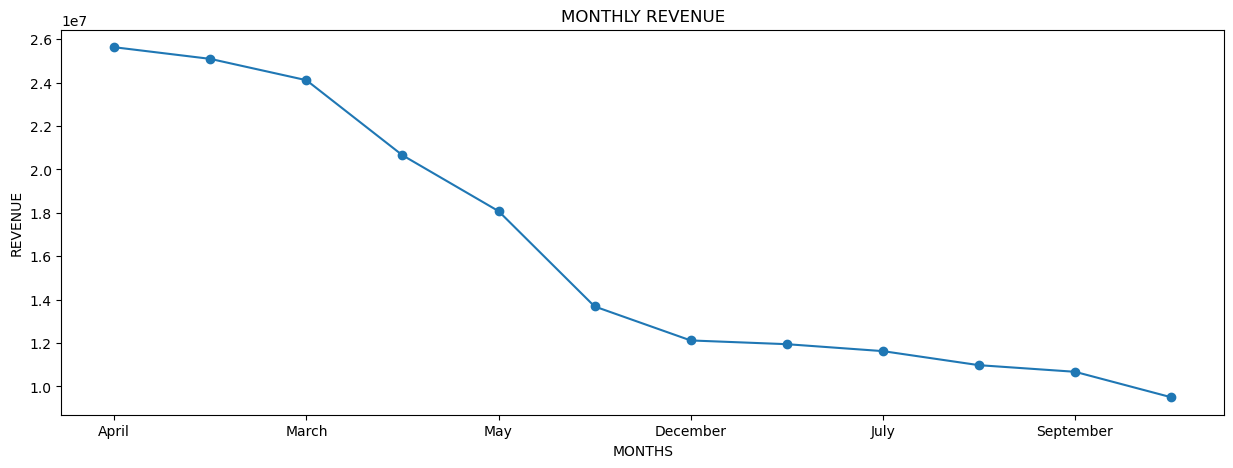

In [57]:
# Monthly Revenue
plt.figure(figsize=(15,5))
monthly_sales.sort_values(ascending = False).plot(kind = 'line',marker = 'o')
plt.title('MONTHLY REVENUE')
plt.xlabel('MONTHS')
plt.ylabel('REVENUE')

In [63]:
# top_product_by revenue
top_product = df.groupby('product_name')['amount'].sum().head(5).astype('int')
top_5_prod =pd.DataFrame(top_product.sort_values(ascending = False))
top_5_prod

,amount
product_name,
Dell Inspiron,20824432
Laptop Bag,20090426
Lenovo IdeaPad,13848926
Keyboard,10722241
HP Pavilion,7418961


Text(0, 0.5, 'Revenue')

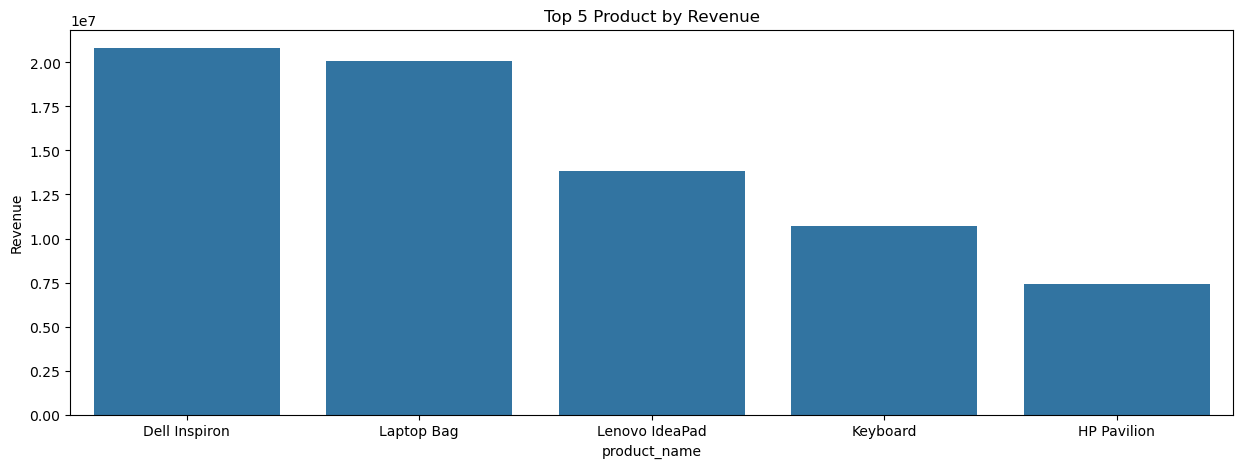

In [66]:
import seaborn as sns
plt.figure(figsize = (15,5))
sns.barplot(x = 'product_name',y= 'amount',data = top_5_prod)
plt.title('Top 5 Product by Revenue')
plt.xlabel('product_name')
plt.ylabel('Revenue')

In [67]:
# TOP 5 CUSTOMER 
top_cust = df.groupby('customer_id')['amount'].sum().head(5).astype(int)
top_5_cust = pd.DataFrame(top_cust.sort_values(ascending = False))
top_5_cust

,amount
customer_id,
C0001,1408209
C0005,960925
C0002,558933
C0003,549168
C0004,60996


Text(0, 0.5, 'Revenue')

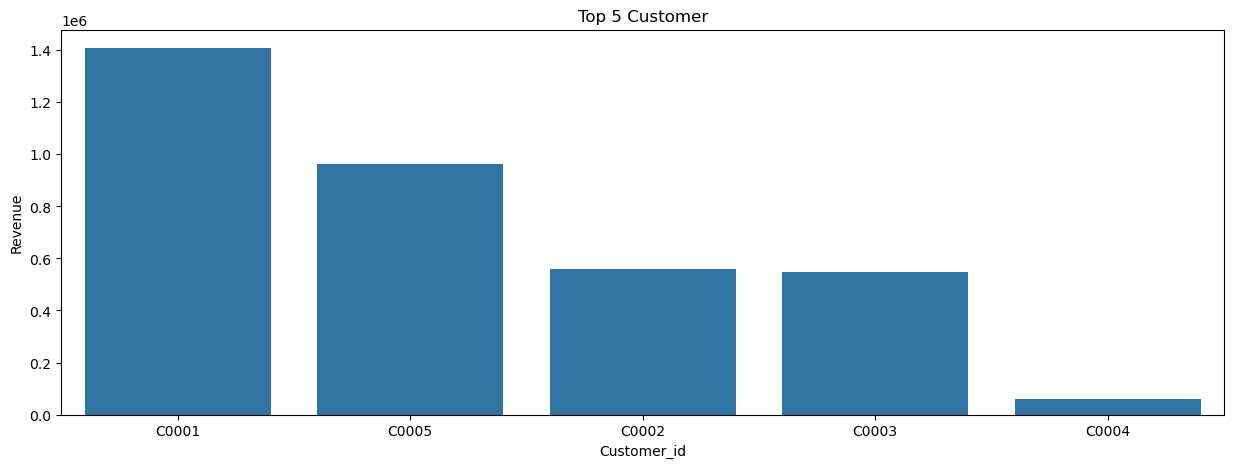

In [71]:
plt.figure(figsize = (15,5))
sns.barplot(x = 'customer_id',y = 'amount',data = top_5_cust)
plt.title('Top 5 Customer')
plt.xlabel('Customer_id')
plt.ylabel('Revenue')

Text(0.5, 1.0, 'Correlation')

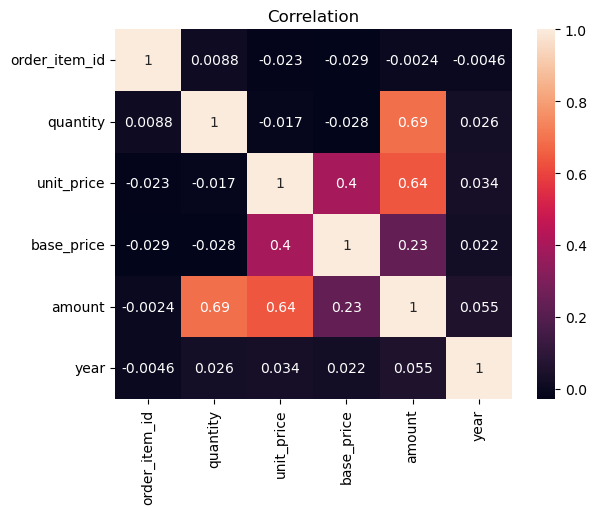

In [78]:
numeric_df = df.select_dtypes(include = np.number)
sns.heatmap(numeric_df.corr(),annot=True)
plt.title('Correlation')

In [79]:
numeric_df.corr()

,order_item_id,quantity,unit_price,base_price,amount,year
order_item_id,1.000000,0.008763,-0.023108,-0.028743,-0.002430,-0.004578
quantity,0.008763,1.000000,-0.016549,-0.028373,0.688234,0.026319
unit_price,-0.023108,-0.016549,1.000000,0.396737,0.636335,0.033557
base_price,-0.028743,-0.028373,0.396737,1.000000,0.233371,0.022155
amount,-0.002430,0.688234,0.636335,0.233371,1.000000,0.054865
year,-0.004578,0.026319,0.033557,0.022155,0.054865,1.000000
